# 070. Poetry text generation - seq2seq Transfer Learning


- 두개의 model 로 구성  
    - model1 : many-to-many RNN model for fine tuning
    - model2 : many-to-many RNN model for sequence-to-sequence prediction
    

- Model 1 에서 Embedding Layer 를 훈련 시키고, 훈련시킨 Embedding 을 Model 2 에서 Text Generation 에 사용  


- Model 1 은 Glove.6B pre-trained weight 를 초기값으로 사용하고, single LSTM 으로 fine tuning  


- Model 2 는 Model 1 에서 train 된 Embedding + LSTM 의 이전 timestep prediction 의 hidden state 와 cell state 를 초기값으로 사용


- Model 2 에서는 idx = np.random.choice(len(probs), p=probs) $\rightarrow$ 사후 확률분포 (posterios probability distribution) 에 의해 next word sampling

<img src="seq2seq.png" width="600"/>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Embedding, Input, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam

In [2]:
# some configuration
MAX_VOCAB_SIZE = 3000
EMBEDDING_DIM = 100
BATCH_SIZE = 128
LATENT_DIM = 25

### input, target data 작성
- input data 와 target data 는 1 timestep offset 차이로 동일  


input data : `<sos> And sorry I could not travel both`  
target data : `And sorry I could not travel both <eos>`

In [3]:
file_path = tf.keras.utils.get_file("robert_frost.txt", "https://github.com/ironmanciti/NLP_lecture/raw/master/data/robert_frost.txt")

In [4]:
# load in the data
input_texts = []
target_texts = []

f = open(file_path,"r", encoding='utf-8')

for i, line in enumerate(f):
    line = line.rstrip()
    if not line:
        continue

    input_line = '<sos> ' + line 
    target_line = line + ' <eos>'

    input_texts.append(input_line)
    target_texts.append(target_line)

print(input_texts[:5])
print()
print(target_texts[:5])

['<sos> Two roads diverged in a yellow wood,', '<sos> And sorry I could not travel both', '<sos> And be one traveler, long I stood', '<sos> And looked down one as far as I could', '<sos> To where it bent in the undergrowth;']

['Two roads diverged in a yellow wood, <eos>', 'And sorry I could not travel both <eos>', 'And be one traveler, long I stood <eos>', 'And looked down one as far as I could <eos>', 'To where it bent in the undergrowth; <eos>']


In [5]:
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='')
tokenizer.fit_on_texts(input_texts + target_texts)

# word index 길이 
word2idx = tokenizer.word_index
print('Found %s unique tokens.' % len(word2idx))

# sanity check --> <sos>, <eos> 가 word dictionary 에 있는지 check
assert('<sos>' in word2idx)
assert('<eos>' in word2idx)

Found 3056 unique tokens.


### sentences (string) 을 integer 로 변환 
- Tokenizer 의 두가지 기능
    - text 내의 word 들을 split 하여 index 부여 (Tokenizer.fit_on_texts)  
    - text 를 word 의 index 로 sequence 변환 (Tokenizer.texts_to_sequences)
    
    
- Tokenizer 의 filters='' 를 해주지 않으면 모든 special character 를 filtering 하므로 `<sos>, <eos>` 의 <, > 가 제거됨  
    - 구둣점들을 filtering 해주지 않아도 최종 performance 에 큰 문제 없음

In [6]:
input_sequences = tokenizer.texts_to_sequences(input_texts)
target_sequences = tokenizer.texts_to_sequences(target_texts)

print(len(input_sequences), len(target_sequences))
print(input_sequences[:3])
print(target_sequences[:3])
print(tokenizer.word_index.get('<sos>'))
print(tokenizer.word_index.get('<eos>'))

1436 1436
[[1, 104, 537, 538, 9, 7, 539, 540], [1, 5, 541, 6, 65, 31, 934, 141], [1, 5, 27, 24, 935, 152, 6, 221]]
[[104, 537, 538, 9, 7, 539, 540, 2], [5, 541, 6, 65, 31, 934, 141, 2], [5, 27, 24, 935, 152, 6, 221, 2]]
1
2


### 모든 input 을 동일한 length 로 padding 하기 위해 max sequence length 구함

In [7]:
# find max seq length
MAX_SEQ_LEN = max(len(s) for s in input_sequences)
print('Max sequence length:', MAX_SEQ_LEN)

Max sequence length: 12


### padding

- 모든 input 과 target 을 동일 length 로 padding  
- max sequence 길이 제한 : min(max_sequence_length_from_data, MAX_SEQUENCE_LENGTH)  
- N x T matrix 생성 (N: sentence 갯수, T: max sequence length) 

In [8]:
# pad sequences so that we get a N x T matrix
input_sequences = pad_sequences(input_sequences, maxlen=MAX_SEQ_LEN, padding='post')
target_sequences = pad_sequences(target_sequences, maxlen=MAX_SEQ_LEN, padding='post')

print(input_sequences.shape)
print(target_sequences.shape)

(1436, 12)
(1436, 12)


In [9]:
num_words = min(MAX_VOCAB_SIZE, len(word2idx) + 1)

### pretrained word embedding 값을 transfer learning

- Embedding layer 의 weight 를 pre-trained model 로 초기화  


- glove.6B 의 EMBEDDING_DIM version 사용  
    - space 로 구분된 text file 
    - 첫번째는 word 이고 두번째 이후는 weight vector 값이다


- word index 가 1 부터 시작하므로 0 padding 감안하여 num_words 는 len(word2idx)+1, 혹은 MAX_VOCAB_SIZE 중 작은 것 선택  


- embedding_dict dictionary : key - word, value - embedding_vector

In [10]:
glove_path = tf.keras.utils.get_file("glove.6B.100d.txt", 
             "https://storage.googleapis.com/laurencemoroney-blog.appspot.com/glove.6B.100d.txt")

In [11]:
def make_embedding(transfer_learning=True):

    embeddings_dict = {}

    with open(glove_path, encoding="utf8") as f:
        for i, line in enumerate(f):
            values = line.split()                                           # 각 줄을 읽어와서 word_vector에 저장
            word = values[0]                                              # 첫번째 값은 word
            coefs = np.asarray(values[1:], dtype='float32')  # 두번째 element 부터 마지막까지 100 개는 해당 단어의 임베딩 벡터의  값
            embeddings_dict[word] = coefs
                
    embedding_matrix = np.zeros((num_words, EMBEDDING_DIM))    # zero 로 초기화   
    
    if transfer_learning:    
        print("word 갯수 =", num_words)
        print(embedding_matrix.shape)

        for word, i in word2idx.items():
            if i < MAX_VOCAB_SIZE:
                embedding_vector = embeddings_dict.get(word)
                if embedding_vector is not None:       # 해당 word 가 없으면 all zero 로 남겨둠
                    embedding_matrix[i] = embedding_vector
                    
    return embedding_matrix

### Embedding layer 작성
- load pre-trained word embeddings into an Embedding layer

In [12]:
embedding_matrix = make_embedding(transfer_learning=True)
embedding_layer = Embedding(num_words, EMBEDDING_DIM, weights=[embedding_matrix])

word 갯수 = 3000
(3000, 100)


In [13]:
# sanity check
print(word2idx["the"])
print(embedding_matrix[3])

3
[-0.038194   -0.24487001  0.72812003 -0.39961001  0.083172    0.043953
 -0.39140999  0.3344     -0.57545     0.087459    0.28786999 -0.06731
  0.30906001 -0.26383999 -0.13231    -0.20757     0.33395001 -0.33848
 -0.31742999 -0.48335999  0.1464     -0.37303999  0.34577     0.052041
  0.44946    -0.46970999  0.02628    -0.54154998 -0.15518001 -0.14106999
 -0.039722    0.28277001  0.14393     0.23464    -0.31020999  0.086173
  0.20397     0.52623999  0.17163999 -0.082378   -0.71787    -0.41531
  0.20334999 -0.12763     0.41367     0.55186999  0.57907999 -0.33476999
 -0.36559001 -0.54856998 -0.062892    0.26583999  0.30204999  0.99774998
 -0.80480999 -3.0243001   0.01254    -0.36941999  2.21670008  0.72201002
 -0.24978     0.92136002  0.034514    0.46744999  1.10790002 -0.19358
 -0.074575    0.23353    -0.052062   -0.22044     0.057162   -0.15806
 -0.30798    -0.41624999  0.37972     0.15006    -0.53211999 -0.20550001
 -1.25259995  0.071624    0.70564997  0.49744001 -0.42063001  0.26148


### create an LSTM network with a single LSTM

- return_sequence = True 일 경우 lstm 의 output 은 x, h, c 
- model 은 [input_, initial_h, initial_c] 의 3 개의 input 과, 하나의 output 을 가진다. initial_state 를 keras default 를 사용하지 않고 직접 control 하기 위해 initial_h 와 initial_c 를 추가  

In [14]:
input1 = Input(shape=(MAX_SEQ_LEN,))
x = embedding_layer(input1)
lstm = LSTM(LATENT_DIM, return_sequences=True)
x = lstm(x)

output1 = Dense(num_words, activation='softmax')(x)
model_1 = Model(input1, output1)

model_1.compile(loss='sparse_categorical_crossentropy', 
                         optimizer=Adam(lr=0.01),
                         metrics=['accuracy'])   # poet 생성에서는 accuracy 큰 의미 없음
model_1.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 12)]              0         
_________________________________________________________________
embedding (Embedding)        (None, 12, 100)           300000    
_________________________________________________________________
lstm (LSTM)                  (None, 12, 25)            12600     
_________________________________________________________________
dense (Dense)                (None, 12, 3000)          78000     
Total params: 390,600
Trainable params: 390,600
Non-trainable params: 0
_________________________________________________________________


In [ ]:
history = model_1.fit(input_sequences, target_sequences, batch_size=BATCH_SIZE, 
                            epochs=40, validation_split=0.2)

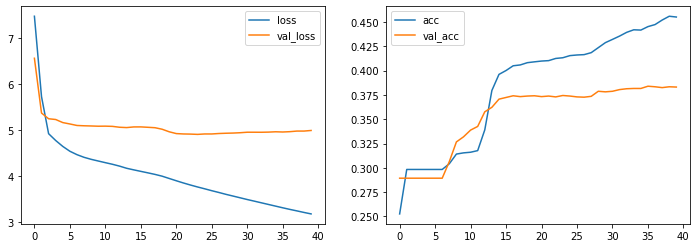

In [16]:
# plot some data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'], label='loss')
ax1.plot(history.history['val_loss'], label='val_loss')
ax1.legend()

# accuracies
ax2.plot(history.history['accuracy'], label='acc')
ax2.plot(history.history['val_accuracy'], label='val_acc')
ax2.legend()
plt.show()

### Poetry 생성 Language Model

- input size = 1  
- model1 에서 작성한 embedding layer 그대로 사용  

In [17]:
# make a sampling model

input2 = Input(shape=(1,))         # 한번에 한 단어만 입력할 것임
x = embedding_layer(input2)
initial_h = Input(shape=(LATENT_DIM,))
initial_c = Input(shape=(LATENT_DIM,))

lstm = LSTM(LATENT_DIM, return_sequences=True, return_state=True)
x, h, c = lstm(x, initial_state=[initial_h, initial_c])

output2 = Dense(num_words, activation='softmax')(x)

model_2 = Model([input2, initial_h, initial_c], [output2, h, c])
model_2.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            [(None, 1)]          0                                            
__________________________________________________________________________________________________
embedding (Embedding)           multiple             300000      input_2[0][0]                    
__________________________________________________________________________________________________
input_3 (InputLayer)            [(None, 25)]         0                                            
__________________________________________________________________________________________________
input_4 (InputLayer)            [(None, 25)]         0                                            
____________________________________________________________________________________________

In [18]:
# reverse word2idx dictionary to get back words during prediction

idx2word = dict((i, w) for w, i in word2idx.items())

In [19]:
np.array([[word2idx['<sos>']]])  # batch size 1, input shape (1,)

array([[1]])

### Poem 생성

- o, h, c 의 shape (1, 1, 3000) (1, 25) (1, 25)  

- print("o.shape:", o.shape, o[0,0,:10])
    - o.shape: (1, 1, 3000) [0.00032528 0.00034357 0.00039464 0.00028656 0.00035617 0.0003263
     0.00037153 0.00029359 0.00032062 0.00030619]
- print(np.argmax(o[0,0]))
    - 46

In [20]:
# generate one line of poem

def sample_line():
  # initial inputs
    np_input = np.array([[ word2idx['<sos>'] ]])     # 첫 word 는 <sos> token
    h = np.zeros((1, LATENT_DIM))                         # Language Model 이므로 초기값 0
    c = np.zeros((1, LATENT_DIM))

    # so we know when to quit
    eos = word2idx['<eos>']

    # store the output here
    output_sentence = []

    for _ in range(MAX_SEQ_LEN):
        o, h, c = model_2.predict([np_input, h, c])        # o - list of word probabilities

        #print("o.shape:", o.shape, o[0,0,:10])
        #print(np.argmax(o[0,0]))
        
        probs = o[0,0]
        
        probs[0] = 0     # 첫번째 word index 는 padding 으로 사용된 0 이므로 선택되지 않도록 확률을 0 으로 setting 함
        
        # next word sampling
        probs /= probs.sum()        # 0 을 제외한 나머지 index 의 확률을 re-nromalize
        idx = np.random.choice(len(probs), p=probs)
        if idx == eos:
            break

        # accumulate output
        output_sentence.append(idx2word.get(idx, f'<OOV {idx}>'))

        # make the next input into model
        np_input[0,0] = idx

    return ' '.join(output_sentence)

# generate a 4 line poem
while True:
    for _ in range(4):
        print(sample_line())

    ans = input("---generate another? [Y/n]---")
    if ans and ans[0].lower().startswith('n'):
        break

woods' least ways 'a 'who'd next nation. lost due aftermath, well, an
asked showed crust. window smash. reeled, strolled blowing another. pole. knock. lets
always. gnaws piece gone- nature. cane nothing's one keep hand. lizard. either
welcomed papered disturbed, sure's place throw allowance, work, won't, forty counts try
---generate another? [Y/n]---y
too idled unprotected else. sweet axis, rock-strewn appears.' bare, soul got year's
deserted. published. friends?' worn lots, we, buttons other unearthly gold fireweed strapping
look- hold reasons; headed fair about. drinking becoming harm baptismal 'aren't myself.
flight perhaps toppling lately? broke 'oh, indian one, about? tote-road. married, playhouse.)
---generate another? [Y/n]---y
stairs. heart. rain?' unafraid, be- double shelf's john-joe, still, axe. suddenly, natural
reasons; gracing year covers, nation meaning weep married- button,' half-drowned 'huh, books
doors snow! summer beat another, orchid choice said. manner nothing des